### Instructions for API extraction  (SKIP)

To start using the notebook:
1. Install dependencies in your .venv:

```
pip install -r requirements.txt
```

2. Go onto https://developer.company-information.service.gov.uk/manage-applications/add, create a new application and create a new key to obtain the API key
3. Create a file named ```.env``` and add your Companies House API key as ```CH_API_KEY=your_actual_api_key_here```. The block below will automatically import your API key, keeping it out of the source control

In [7]:
# import os
# from dotenv import load_dotenv

In [8]:
# # Load your .env API key
# load_dotenv()

# CH_API_KEY = os.getenv("CH_API_KEY")

# if not CH_API_KEY:
#     raise ValueError("CH_API_KEY not found. Check your .env file.")

### Instructions for bulk download

Go onto https://download.companieshouse.gov.uk/en_output.html and download the zipped file for Companies Records.

In [9]:
import pandas as pd

In [10]:
CSV_PATH = "../notebooks/BasicCompanyDataAsOneFile-2026-06-01.csv"

### EDA - Bulk Company Data

In [38]:
df_head = pd.read_csv(CSV_PATH, nrows=5)
df_head

,CompanyName,CompanyNumber,RegAddress.CareOf,RegAddress.POBox,RegAddress.AddressLine1,RegAddress.AddressLine2,RegAddress.PostTown,RegAddress.County,RegAddress.Country,RegAddress.PostCode,...,PreviousName_7.CONDATE,PreviousName_7.CompanyName,PreviousName_8.CONDATE,PreviousName_8.CompanyName,PreviousName_9.CONDATE,PreviousName_9.CompanyName,PreviousName_10.CONDATE,PreviousName_10.CompanyName,ConfStmtNextDueDate,ConfStmtLastMadeUpDate
0,! LTD,8209948,NaN,NaN,9 PRINCES SQUARE,NaN,HARROGATE,NaN,ENGLAND,HG1 1ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25/09/2026,11/09/2025
1,!ABRIDGE TAX LTD,16092999,NaN,NaN,82 GREAT NORTH ROAD,GREAT NORTH BUSINESS CENTRE,HATFIELD,NaN,UNITED KINGDOM,AL9 5BL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04/12/2026,20/11/2025
2,!BIG IMPACT GRAPHICS LIMITED,11743365,NaN,NaN,124 CITY ROAD,NaN,LONDON,NaN,NaN,EC1V 2NX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29/12/2026,15/12/2025
3,!FE NETWORK LIMITED,16873705,NaN,NaN,C/O AACSL ACCOUNTANT LIMITED,1ST FLOOR NORTH WESTGATE HOUSE,"HARLOW, ESSEX",NaN,UNITED KINGDOM,CM20 1YS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08/12/2026,NaN
4,!NFLECTION ADVISORY LIMITED,15073164,NaN,NaN,74 SANTERS LANE,NaN,POTTERS BAR,HERTFORDSHIRE,ENGLAND,EN6 2DA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28/08/2026,14/08/2025


In [39]:
print(df_head.dtypes)

CompanyName                            object
 CompanyNumber                          int64
RegAddress.CareOf                     float64
RegAddress.POBox                      float64
RegAddress.AddressLine1                object
 RegAddress.AddressLine2               object
RegAddress.PostTown                    object
RegAddress.County                      object
RegAddress.Country                     object
RegAddress.PostCode                    object
CompanyCategory                        object
CompanyStatus                          object
CountryOfOrigin                        object
DissolutionDate                       float64
IncorporationDate                      object
Accounts.AccountRefDay                  int64
Accounts.AccountRefMonth                int64
Accounts.NextDueDate                   object
Accounts.LastMadeUpDate                object
Accounts.AccountCategory               object
Returns.NextDueDate                    object
Returns.LastMadeUpDate            

In [40]:
SAMPLE_N = 50_000
df = pd.read_csv(CSV_PATH, nrows=SAMPLE_N, low_memory=False)

date_cols = [
    "IncorporationDate", "DissolutionDate",
    "Accounts.NextDueDate", "Accounts.LastMadeUpDate",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

print(f"Shape: {df.shape}")
df.dtypes

Shape: (50000, 55)


CompanyName                                   object
 CompanyNumber                                object
RegAddress.CareOf                             object
RegAddress.POBox                              object
RegAddress.AddressLine1                       object
 RegAddress.AddressLine2                      object
RegAddress.PostTown                           object
RegAddress.County                             object
RegAddress.Country                            object
RegAddress.PostCode                           object
CompanyCategory                               object
CompanyStatus                                 object
CountryOfOrigin                               object
DissolutionDate                       datetime64[ns]
IncorporationDate                     datetime64[ns]
Accounts.AccountRefDay                       float64
Accounts.AccountRefMonth                     float64
Accounts.NextDueDate                  datetime64[ns]
Accounts.LastMadeUpDate               datetime

In [41]:
null_summary = df.isnull().sum().rename("null_count").to_frame()
null_summary["null_pct"] = (null_summary["null_count"] / len(df) * 100).round(1)
null_summary.sort_values("null_pct", ascending=False)

,null_count,null_pct
PreviousName_7.CONDATE,49997,100.0
PreviousName_9.CONDATE,49998,100.0
PreviousName_5.CONDATE,49987,100.0
PreviousName_5.CompanyName,49987,100.0
PreviousName_6.CONDATE,49995,100.0
PreviousName_6.CompanyName,49995,100.0
PreviousName_7.CompanyName,49997,100.0
DissolutionDate,50000,100.0
PreviousName_8.CONDATE,49997,100.0
PreviousName_8.CompanyName,49997,100.0


In [42]:
for col in ["CompanyCategory", "CompanyStatus", "CountryOfOrigin", "Accounts.AccountCategory"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- CompanyCategory ---
CompanyCategory
Private Limited Company                                                                      41321
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                         7423
Overseas Entity                                                                                285
Limited Liability Partnership                                                                  257
Limited Partnership                                                                            212
Community Interest Company                                                                     176
Charitable Incorporated Organisation                                                            88
Other company type                                                                              67
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)       61
Public Limited Company                                              

In [43]:
df.select_dtypes("number").describe()

,Accounts.AccountRefDay,Accounts.AccountRefMonth,Mortgages.NumMortCharges,Mortgages.NumMortOutstanding,Mortgages.NumMortPartSatisfied,Mortgages.NumMortSatisfied,LimitedPartnerships.NumGenPartners,LimitedPartnerships.NumLimPartners
count,49362.000000,49362.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.00000
mean,30.120903,6.457093,0.373500,0.213940,0.000340,0.15896,0.00440,0.01618
std,2.723617,3.599018,3.824815,1.190864,0.020491,3.52081,0.07029,0.61156
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
25%,30.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
50%,31.000000,6.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
75%,31.000000,10.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
max,31.000000,12.000000,718.000000,96.000000,2.000000,718.00000,3.00000,72.00000


In [44]:
df["SICCode.SicText_1"].value_counts().head(20)

SICCode.SicText_1
98000 - Residents property management                                        15113
68209 - Other letting and operating of own or leased real estate              4334
68100 - Buying and selling of own real estate                                 2799
68320 - Management of real estate on a fee or contract basis                  2094
99999 - Dormant Company                                                       1205
None Supplied                                                                 1153
82990 - Other business support service activities n.e.c.                      1086
70229 - Management consultancy activities other than financial management     1076
96090 - Other service activities n.e.c.                                        837
41100 - Development of building projects                                       804
62020 - Information technology consultancy activities                          753
74990 - Non-trading company                                          

<Axes: title={'center': 'Incorporations by Year'}, xlabel='IncorporationDate'>

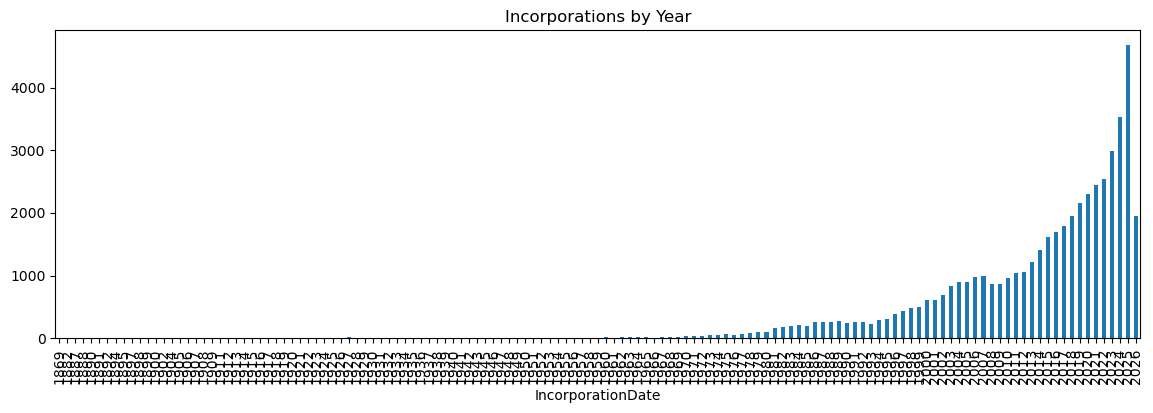

In [45]:
df["IncorporationDate"].dt.year.value_counts().sort_index().plot(
    kind="bar", figsize=(14, 4), title="Incorporations by Year"
)

<Axes: title={'center': 'Company Status Distribution'}, xlabel='CompanyStatus'>

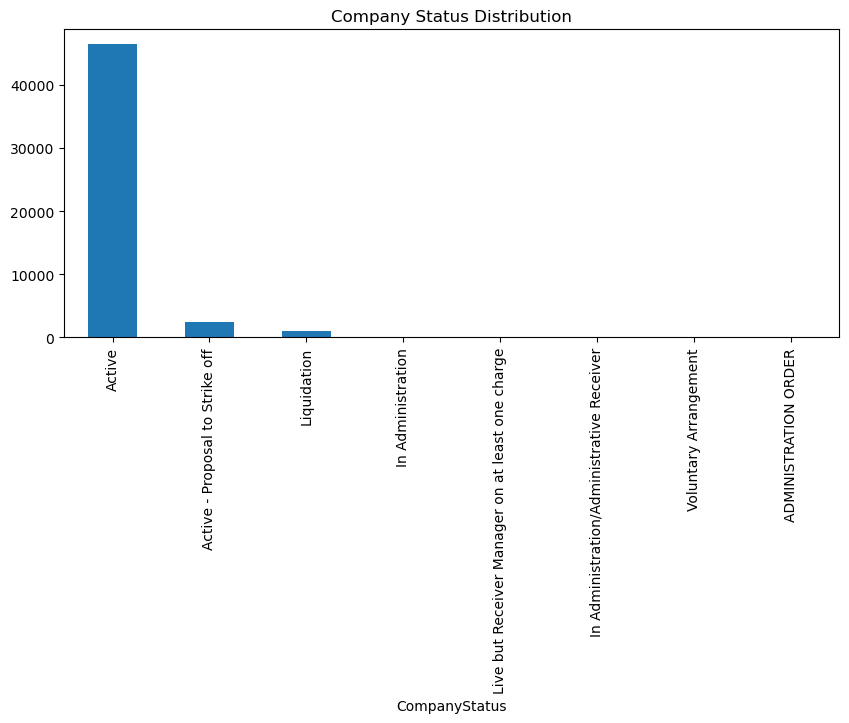

In [46]:
df["CompanyStatus"].value_counts().plot(
    kind="bar", figsize=(10, 4), title="Company Status Distribution"
)

Filtering: Building on what is previously done, Create the static dataset.

Filter the bulk Companies House data to the target universe agreed with Lloyds:
- **Sectors**: Technology, Legal & Professional Services, Manufacturing, Fast Growth & Emerging
- **Status**: Active companies only
- **Size proxy**: Account category as a turnover proxy (BB < £3m, SME £3–25m)

In [47]:
#Extractin the numeric SIC code

#I'll extract just the 5-digit code and the 2-igit division for sector mapping
df["sic_code"] = (
    df["SICCode.SicText_1"]
    .str.extract(r"^(\d+)", expand=False)
    .astype("Int64")  # nullable integer to handle NaN
)
 
df["sic_division"] = df["sic_code"] // 1000  # first 2 digits (e.g., 62020 -> 62)

print(f"Companies with valid SIC code: {df['sic_code'].notna().sum():,}")
print(f"Companies with missing/unparseable SIC: {df['sic_code'].isna().sum():,}")
print(f"\nTop 15 SIC divisions:")
print(df["sic_division"].value_counts().head(15))


Companies with valid SIC code: 48,847
Companies with missing/unparseable SIC: 1,153

Top 15 SIC divisions:
sic_division
98    15180
68     9466
47     1687
62     1503
56     1375
74     1327
70     1323
82     1225
99     1211
41     1188
96     1181
43     1176
64      976
55      741
46      661
Name: count, dtype: Int64


In [48]:
#Defining sector to SIC mapping

#mapping the agreed target secors to SIC division codes (2-digit level).

SECTOR_MAPPING = {
    "Technology": [
        61,  # Telecommunications
        62,  # Computer programming, consultancy and related activities
        63,  # Information service activities
    ],
    "Legal & Professional Services": [
        69,  # Legal and accounting activities
        70,  # Head offices; management consultancy
        71,  # Architectural and engineering; technical testing
        72,  # Scientific research and development
        73,  # Advertising and market research
        74,  # Other professional, scientific and technical activities
    ],
    "Manufacturing": list(range(10, 34)),  # SIC divisions 10-33
    "Fast Growth & Emerging": [
        # These are judgement calls — discuss with the team and adjust
        26,  # Manufacture of computer, electronic and optical products
        21,  # Manufacture of pharma or biotech
        35,  # Electricity, gas (which includes renewables)
        # NOTE: 62 and 63 already captured under Technology
        # You may also want to add fintech (subset of 64) — discuss with team
    ],
}
 
# Flatten to a lookup: sic_division -> sector name
sic_to_sector = {}
for sector, divisions in SECTOR_MAPPING.items():
    for div in divisions:
        # If a division appears in multiple sectors, keep the first mapping
        # (e.g., 26 is both Manufacturing and Fast Growth, Manufacturing takes priority)
        if div not in sic_to_sector:
            sic_to_sector[div] = sector
 
print("SIC division -> Sector mapping:")
for div in sorted(sic_to_sector.keys()):
    print(f"  {div}: {sic_to_sector[div]}")

SIC division -> Sector mapping:
  10: Manufacturing
  11: Manufacturing
  12: Manufacturing
  13: Manufacturing
  14: Manufacturing
  15: Manufacturing
  16: Manufacturing
  17: Manufacturing
  18: Manufacturing
  19: Manufacturing
  20: Manufacturing
  21: Manufacturing
  22: Manufacturing
  23: Manufacturing
  24: Manufacturing
  25: Manufacturing
  26: Manufacturing
  27: Manufacturing
  28: Manufacturing
  29: Manufacturing
  30: Manufacturing
  31: Manufacturing
  32: Manufacturing
  33: Manufacturing
  35: Fast Growth & Emerging
  61: Technology
  62: Technology
  63: Technology
  69: Legal & Professional Services
  70: Legal & Professional Services
  71: Legal & Professional Services
  72: Legal & Professional Services
  73: Legal & Professional Services
  74: Legal & Professional Services


In [49]:
#Applying the sector wise filtering

df["sector"] = df["sic_division"].map(sic_to_sector)
 
# Keep only companies in our target sectors
df_sector = df[df["sector"].notna()].copy()
 
print(f"Companies in target sectors: {df_sector.shape[0]:,} "
      f"({df_sector.shape[0] / df.shape[0] * 100:.1f}% of total)")
print(f"\nBreakdown by sector:")
print(df_sector["sector"].value_counts())

Companies in target sectors: 6,219 (12.4% of total)

Breakdown by sector:
sector
Legal & Professional Services    3589
Technology                       1776
Manufacturing                     808
Fast Growth & Emerging             46
Name: count, dtype: int64


In [50]:
#Apply status filter, as in active only companies

df_active = df_sector[df_sector["CompanyStatus"] == "Active"].copy()
 
print(f"Active companies in target sectors: {df_active.shape[0]:,}")
print(f"Dropped {df_sector.shape[0] - df_active.shape[0]:,} non-active companies")
print(f"\nDropped statuses:")
print(df_sector[df_sector["CompanyStatus"] != "Active"]["CompanyStatus"].value_counts())

Active companies in target sectors: 5,579
Dropped 640 non-active companies

Dropped statuses:
CompanyStatus
Active - Proposal to Strike off    487
Liquidation                        142
In Administration                   10
Voluntary Arrangement                1
Name: count, dtype: int64


In [51]:
#Apply size filter using AccoutCategory as turnover proxy


Applying size filter using AccountCategory as turnover proxy

Companies Act Thresholds (approx):
- **micro enty**:  → turnover ≤ £632k    → clearly BB tier
- **small**:  → turnover ≤ £10.2m   → spans BB and SME
- **total exemption(*)**: → small company exemptions → likely BB/SME
- **unaudited abridged**: → small/medium  → likely SME
- **medium**: → turnover ≤ £36m  → upper SME range
- **full**: →this could be any size → may exceed £25m

thus for Lloyds target (BB <£3m + SME £3-25m), I'll include the following categories


In [52]:
TARGET_ACCOUNT_CATEGORIES = [
    "MICRO ENTITY",
    "SMALL",
    "TOTAL EXEMPTION FULL",
    "TOTAL EXEMPTION SMALL",
    "UNAUDITED ABRIDGED",
    "AUDIT EXEMPTION SUBSIDIARY",
    # Optionally include MEDIUM if you want broader coverage
    # "MEDIUM",
]
 
# Also see what categories exist in the filtered data
print("Account categories in filtered data:")
print(df_active["Accounts.AccountCategory"].value_counts())
print()
 
df_sized = df_active[
    df_active["Accounts.AccountCategory"].isin(TARGET_ACCOUNT_CATEGORIES)
].copy()
 
print(f"After size filter: {df_sized.shape[0]:,} companies")
print(f"Dropped {df_active.shape[0] - df_sized.shape[0]:,} companies "
      f"(DORMANT, NO ACCOUNTS FILED, FULL, etc.)")

Account categories in filtered data:
Accounts.AccountCategory
MICRO ENTITY                   2065
TOTAL EXEMPTION FULL           1159
NO ACCOUNTS FILED              1081
DORMANT                        1000
UNAUDITED ABRIDGED              118
FULL                             42
AUDIT EXEMPTION SUBSIDIARY       36
SMALL                            35
GROUP                            25
TOTAL EXEMPTION SMALL            11
MEDIUM                            4
FILING EXEMPTION SUBSIDIARY       1
ACCOUNTS TYPE NOT AVAILABLE       1
AUDITED ABRIDGED                  1
Name: count, dtype: int64

After size filter: 3,424 companies
Dropped 2,155 companies (DORMANT, NO ACCOUNTS FILED, FULL, etc.)


In [54]:
#Assigning Lloyds tier label based on size and sector
#this would be a rough tier assignment based on account category

def assign_tier(category: str) -> str:
    if category == "MICRO ENTITY":
        return "BB (<£3m)"
    elif category in ["SMALL", "TOTAL EXEMPTION FULL", "TOTAL EXEMPTION SMALL",
                       "AUDIT EXEMPTION SUBSIDIARY"]:
        return "BB/SME (uncertain)"  # Could be either — no clean split
    elif category in ["UNAUDITED ABRIDGED", "MEDIUM"]:
        return "SME (£3-25m)"
    return "Unknown"
 
df_sized["lloyds_tier"] = df_sized["Accounts.AccountCategory"].apply(assign_tier)
 
print("Lloyds tier distribution:")
print(df_sized["lloyds_tier"].value_counts())


Lloyds tier distribution:
lloyds_tier
BB (<£3m)             2065
BB/SME (uncertain)    1241
SME (£3-25m)           118
Name: count, dtype: int64


In [ ]:
#Will drop high-null columns and clean up
# PreviousName columns (3-10) are 95-100% null — drop them
cols_to_drop = [col for col in df_sized.columns if "PreviousName" in col
                and any(f"_{i}." in col for i in range(3, 11))]
 
# Also drop columns we don't need downstream
cols_to_drop += [
    "RegAddress.CareOf",    
    "RegAddress.POBox",      
    "LimitedPartnerships.NumGenPartners",  
    "LimitedPartnerships.NumLimPartners",  
    "Returns.NextDueDate",   
    "Returns.LastMadeUpDate",
]
 
df_clean = df_sized.drop(columns=[c for c in cols_to_drop if c in df_sized.columns])
 
print(f"Columns reduced: {df_sized.shape[1]} -> {df_clean.shape[1]}")
print(f"Remaining columns: {list(df_clean.columns)}")

Columns reduced: 59 -> 37
Remaining columns: ['CompanyName', ' CompanyNumber', 'RegAddress.AddressLine1', ' RegAddress.AddressLine2', 'RegAddress.PostTown', 'RegAddress.County', 'RegAddress.Country', 'RegAddress.PostCode', 'CompanyCategory', 'CompanyStatus', 'CountryOfOrigin', 'DissolutionDate', 'IncorporationDate', 'Accounts.AccountRefDay', 'Accounts.AccountRefMonth', 'Accounts.NextDueDate', 'Accounts.LastMadeUpDate', 'Accounts.AccountCategory', 'Mortgages.NumMortCharges', 'Mortgages.NumMortOutstanding', 'Mortgages.NumMortPartSatisfied', 'Mortgages.NumMortSatisfied', 'SICCode.SicText_1', 'SICCode.SicText_2', 'SICCode.SicText_3', 'SICCode.SicText_4', 'URI', 'PreviousName_1.CONDATE', ' PreviousName_1.CompanyName', ' PreviousName_2.CONDATE', ' PreviousName_2.CompanyName', 'ConfStmtNextDueDate', ' ConfStmtLastMadeUpDate', 'sic_code', 'sic_division', 'sector', 'lloyds_tier']


In [57]:
#Computing company age
import numpy as np
 
df_clean["company_age_years"] = (
    (pd.Timestamp.now() - df_clean["IncorporationDate"]).dt.days / 365.25
).round(1)
 
print("Company age distribution (years):")
print(df_clean["company_age_years"].describe())

Company age distribution (years):
count    3424.000000
mean       11.130053
std         9.109875
min         0.600000
25%         4.700000
50%         8.700000
75%        15.000000
max       139.300000
Name: company_age_years, dtype: float64


In [58]:
#Summary for the filtered static dataset
print("Dataset summary")
print("Total companies:", len(df_clean))
print("Columns:", df_clean.shape[1])

print("\nSector breakdown:")
print(df_clean["sector"].value_counts())

print("\nLloyds tier breakdown:")
print(df_clean["lloyds_tier"].value_counts())

print("\nAccount category breakdown:")
print(df_clean["Accounts.AccountCategory"].value_counts())

print("\nCompany age (years):")
print("  median:", round(df_clean["company_age_years"].median(), 1))
print("  mean:  ", round(df_clean["company_age_years"].mean(), 1))

print("\nSample of 10 companies:")
df_clean[["CompanyName", "sector", "lloyds_tier", "company_age_years"]].sample(10, random_state=42)


Dataset summary
Total companies: 3424
Columns: 38

Sector breakdown:
sector
Legal & Professional Services    1987
Technology                        970
Manufacturing                     435
Fast Growth & Emerging             32
Name: count, dtype: int64

Lloyds tier breakdown:
lloyds_tier
BB (<£3m)             2065
BB/SME (uncertain)    1241
SME (£3-25m)           118
Name: count, dtype: int64

Account category breakdown:
Accounts.AccountCategory
MICRO ENTITY                  2065
TOTAL EXEMPTION FULL          1159
UNAUDITED ABRIDGED             118
AUDIT EXEMPTION SUBSIDIARY      36
SMALL                           35
TOTAL EXEMPTION SMALL           11
Name: count, dtype: int64

Company age (years):
  median: 8.7
  mean:   11.1

Sample of 10 companies:


,CompanyName,sector,lloyds_tier,company_age_years
11673,123 MEDICAL LTD,Legal & Professional Services,BB/SME (uncertain),6.6
28522,20 TEN B&M LIMITED,Legal & Professional Services,BB/SME (uncertain),4.6
37737,2779 PRECINCT MARKET COVENTRY (FREEHOLDCO) LIM...,Legal & Professional Services,BB/SME (uncertain),10.9
17966,160 DIGITAL LTD,Technology,BB (<£3m),2.6
6063,100STARLINGS LIMITED,Technology,BB/SME (uncertain),11.2
37003,26B RAILWAY COMPANY LIMITED,Manufacturing,BB/SME (uncertain),42.3
30686,21C DEVELOPMENTS LIMITED,Legal & Professional Services,BB/SME (uncertain),20.7
39744,2C DESIGN CONSULTANTS LIMITED,Legal & Professional Services,BB/SME (uncertain),22.4
2348,09588692 LTD,Technology,BB/SME (uncertain),11.1
48654,360 ORTHODONTICS LIMITED,Technology,BB/SME (uncertain),26.9
